# Практика 19. Класифікація математичних моделей та перевірка адекватності

**Студент:** Коць Артем  
**Група:** ІТ-42  
**Варіант:** 9  
**Місто:** Суми

## Мета роботи

Класифікувати математичну модель за незалежними ознаками,
побудувати найпростішу лінійну модель прогнозування місячного
споживання електроенергії за температурою, оцінити її адекватність
за коефіцієнтом детермінації та структурою залишків, а також
розмежувати верифікацію і валідацію моделі.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
np.random.seed(9)

city = "Суми"
base_temp = 7.5
amplitude = 14
base_consumption = 950
k = 24
noise_sd = 28

months = np.arange(1, 13)

temp = base_temp + amplitude * np.cos(
    (months - 7) / 12 * 2 * np.pi
)

temp = np.round(
    temp + np.random.normal(0, 0.5, size=12),
    1
)

consumption = (
    base_consumption
    - k * (temp - base_temp)
    + np.random.normal(0, noise_sd, size=12)
)

consumption = np.round(consumption, 0)

city_data = pd.DataFrame({
    "місяць": months,
    "температура": temp,
    "споживання_МВтгод": consumption,
})

print("Студент: Коць Артем")
print("Група: ІТ-42")
print("Варіант: 9")
print("Місто: Суми")

display(city_data)

Студент: Коць Артем
Група: ІТ-42
Варіант: 9
Місто: Суми


,місяць,температура,споживання_МВтгод
0,1,-6.5,1294.0
1,2,-4.8,1265.0
2,3,-0.1,1183.0
3,4,7.5,962.0
4,5,14.3,830.0
5,6,19.4,639.0
6,7,20.7,629.0
7,8,19.4,701.0
8,9,14.4,803.0
9,10,7.2,958.0


## Завдання 1. Класифікація сценарію

### 1. Детермінована чи стохастична

Модель має вигляд:

`споживання = a + b · температура`

Її середня частина є детермінованою, оскільки для заданої
температури формула однозначно визначає прогноз.

Проте фактичні дані містять випадкову складову `noise_sd`, яка
моделює вплив інших факторів та похибку спостережень.

Тому модель у цілому є **стохастичною**: вона складається з
детермінованої середньої залежності та випадкового залишку.

### 2. Балансова, оптимізаційна, імітаційна чи жодна

Ця модель не є балансовою, оскільки не описує закон збереження
або рівність між потоками ресурсів.

Вона не є оптимізаційною, оскільки не здійснює пошук найкращого
рішення серед допустимих варіантів.

Вона також не є імітаційною, оскільки не відтворює покрокову
динаміку системи в часі.

Отже, модель належить до **описових/прогнозних статистичних моделей**
і не є жодною з трьох перелічених категорій.

### 3. Статична чи динамічна

Модель є **статичною**.

Передбачення споживання електроенергії для конкретного місяця
залежить від температури цього самого місяця. Значення споживання
попередніх місяців не входять до формули.

Той факт, що спостереження отримані протягом 12 послідовних місяців,
сам по собі не робить модель динамічною.

In [3]:
b, a = np.polyfit(
    city_data["температура"],
    city_data["споживання_МВтгод"],
    1
)

print(f"споживання ≈ {a:.1f} + ({b:.1f}) · температура")

city_data["передбачення"] = (
    a + b * city_data["температура"]
)

display(city_data)

споживання ≈ 1149.8 + (-24.5) · температура


,місяць,температура,споживання_МВтгод,передбачення
0,1,-6.5,1294.0,1308.726493
1,2,-4.8,1265.0,1267.153398
2,3,-0.1,1183.0,1152.216015
3,4,7.5,962.0,966.359821
4,5,14.3,830.0,800.067438
5,6,19.4,639.0,675.348150
6,7,20.7,629.0,643.556959
7,8,19.4,701.0,675.348150
8,9,14.4,803.0,797.621962
9,10,7.2,958.0,973.696250


## Інтерпретація коефіцієнта b

Коефіцієнт `b` показує, наскільки в середньому змінюється
місячне споживання електроенергії при зміні температури на 1 °C.

Оскільки нижча температура збільшує потребу в опаленні,
очікується від'ємний знак коефіцієнта `b`.

Отримане у моделі значення `b` має від'ємний знак, що узгоджується
з початковим припущенням: зі зростанням температури потреба
в електроенергії на опалення зменшується.

In [4]:
city_data["залишок"] = (
    city_data["споживання_МВтгод"]
    - city_data["передбачення"]
)

residuals = city_data["залишок"]

ss_res = (residuals ** 2).sum()

ss_tot = (
    (
        city_data["споживання_МВтгод"]
        - city_data["споживання_МВтгод"].mean()
    ) ** 2
).sum()

r_squared = 1 - ss_res / ss_tot

print(f"R² = {r_squared:.6f}")

display(
    city_data[
        [
            "місяць",
            "температура",
            "споживання_МВтгод",
            "передбачення",
            "залишок"
        ]
    ].round(2)
)

R² = 0.993070


,місяць,температура,споживання_МВтгод,передбачення,залишок
0,1,-6.5,1294.0,1308.73,-14.73
1,2,-4.8,1265.0,1267.15,-2.15
2,3,-0.1,1183.0,1152.22,30.78
3,4,7.5,962.0,966.36,-4.36
4,5,14.3,830.0,800.07,29.93
5,6,19.4,639.0,675.35,-36.35
6,7,20.7,629.0,643.56,-14.56
7,8,19.4,701.0,675.35,25.65
8,9,14.4,803.0,797.62,5.38
9,10,7.2,958.0,973.70,-15.70


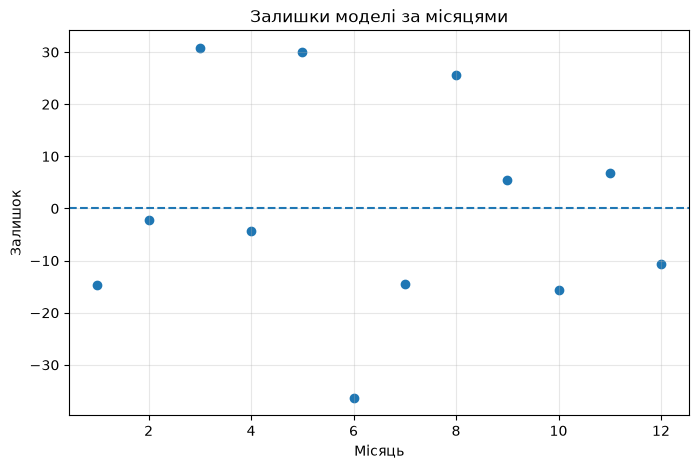

In [5]:
plt.figure(figsize=(8, 5))

plt.scatter(
    city_data["місяць"],
    city_data["залишок"]
)

plt.axhline(0, linestyle="--")

plt.xlabel("Місяць")
plt.ylabel("Залишок")
plt.title("Залишки моделі за місяцями")

plt.grid(True, alpha=0.3)
plt.show()

## Аналіз залишків

Залишки показують різницю між фактичним та передбаченим
споживанням електроенергії.

Для адекватної лінійної моделі бажано, щоб залишки були
розкидані навколо нульової лінії без чіткої систематичної
закономірності.

На отриманому графіку залишки змінюють знак і розташовані
по обидва боки від нульової лінії. Вираженого систематичного
тренду не спостерігається.

Це свідчить, що лінійна модель достатньо добре описує
залежність споживання електроенергії від температури
для сформованих даних.

In [6]:
first_month = city_data.iloc[0]

manual_prediction = a + b * first_month["температура"]
code_prediction = first_month["передбачення"]

print("=== ВЕРИФІКАЦІЯ ===")
print(f"Місяць: {int(first_month['місяць'])}")
print(f"Температура: {first_month['температура']} °C")

print(f"\nРучний розрахунок: {manual_prediction:.2f}")
print(f"Результат коду:     {code_prediction:.2f}")

print(
    "\nРезультати збігаються:",
    np.isclose(manual_prediction, code_prediction)
)

=== ВЕРИФІКАЦІЯ ===
Місяць: 1
Температура: -6.5 °C

Ручний розрахунок: 1308.73
Результат коду:     1308.73

Результати збігаються: True


## Завдання 4. Верифікація і валідація

### Верифікація

Верифікація цього коду означає перевірку правильності реалізації
математичної формули. Для цього для першого місяця було виконано
ручний розрахунок за формулою `a + b · температура` та порівняно
його з результатом, отриманим програмою.

Збіг двох результатів підтверджує, що формула передбачення
реалізована в коді правильно.

### Валідація

Валідація означає перевірку того, наскільки побудована модель
відповідає реальним спостереженням і чи може вона узагальнюватися
на нові дані.

Тих самих 12 спостережень недостатньо для повної чесної валідації,
оскільки саме на них були оцінені коефіцієнти `a` і `b`.

Для повноцінної перевірки бажано використати нові дані, наприклад
спостереження за наступний рік, які не використовувалися під час
підбору моделі. Це дозволить перевірити, наскільки добре модель
прогнозує невідомі їй спостереження.

In [7]:
print("=== ОЦІНКА АДЕКВАТНОСТІ МОДЕЛІ ===")
print(f"R² = {r_squared:.6f}")

if r_squared >= 0.8:
    print("R² достатньо високе — модель добре пояснює варіацію споживання.")
    print("Додаткове ускладнення моделі для поточної мети не є необхідним.")
else:
    print("R² відносно низьке — модель можна вдосконалити.")

=== ОЦІНКА АДЕКВАТНОСТІ МОДЕЛІ ===
R² = 0.993070
R² достатньо високе — модель добре пояснює варіацію споживання.
Додаткове ускладнення моделі для поточної мети не є необхідним.


## Завдання 5. Пропозиція вдосконалення моделі

Для поточного набору даних базова лінійна модель є достатньо
простою та зрозумілою для прогнозування місячного споживання
електроенергії за температурою.

Якщо залишки не мають вираженої систематичної структури, додаткове
ускладнення моделі не є необхідним. У такому випадку простіша
модель має перевагу: її легше інтерпретувати, перевіряти та
використовувати для прогнозування.

Отже, з урахуванням компромісу між точністю та складністю моделі,
для поточного завдання доцільно залишити лінійну модель
`споживання = a + b · температура`.

Для практичного прогнозування на нові періоди модель у подальшому
можна перевірити на даних наступного року.

# Контрольні питання

### 1. За якими незалежними ознаками класифікується модель?

Модель класифікується за трьома незалежними ознаками.

За характером випадковості вона є стохастичною, оскільки
детермінована лінійна залежність доповнюється випадковим шумом.

За типом математичної моделі вона не є балансовою, оптимізаційною
або імітаційною. Це описова/прогнозна статистична модель.

За характером зміни стану вона є статичною, оскільки прогноз
конкретного місяця залежить від температури цього місяця,
а не від попередніх значень споживання.

Ці ознаки не суперечать одна одній, оскільки описують різні
властивості моделі.

### 2. Що показує отримане R²?

R² показує частку варіації місячного споживання електроенергії,
яку пояснює температура в побудованій лінійній моделі.

Високе R² означає, що модель добре описує саме наявні
спостереження. Проте високе R² саме по собі не доводить,
що модель є правильною або придатною для екстраполяції
за межі спостереженого діапазону температур.

Для оцінки адекватності також потрібно аналізувати залишки
та перевіряти модель на нових даних.

### 3. Чому структура залишків важливіша за лише їхню сумарну величину?

Сумарна величина залишків показує загальний рівень помилки,
але не показує, чи є ця помилка випадковою.

Якщо залишки мають систематичний тренд або закономірність,
це може свідчити про те, що модель не враховує важливу
залежність.

Якщо залишки випадково розкидані навколо нуля без вираженої
структури, це є аргументом на користь адекватності моделі.

Тому для оцінювання моделі важливо поєднувати числові показники
з аналізом структури залишків.